# lab-1

## 2. exploratory data analysis

### import and reading data

In [471]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid')

RANDOM_STATE = 42

In [472]:
df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [473]:
rows, columns = df.shape

print('Rows:\t', rows)
print('Columns:', f"{columns}\n")

df.info()

Rows:	 1460
Columns: 81

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  

In [474]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [475]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [476]:
df.describe(include=['str']).T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [477]:
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()
print('Number of categorical columns:\t', len(categorical_cols))

top_value = [
    (lambda m: m.iloc[0] if not m.empty else None)(df[c].mode(dropna=True))
    for c in categorical_cols
]

top_freq_share = [
    (lambda f: f.iloc[0] if f.size else np.nan)(df[c].value_counts(normalize=True, dropna=True))
    for c in categorical_cols
]

cat_summary = pd.DataFrame({
    'n_unique': df[categorical_cols].nunique(), 
    'top_value': top_value,
    'top_freq_share': top_freq_share,
}).sort_values('n_unique', ascending=False)

cat_summary


Number of categorical columns:	 43


,n_unique,top_value,top_freq_share
Neighborhood,25,NAmes,0.154110
Exterior2nd,16,VinylSd,0.345205
Exterior1st,15,VinylSd,0.352740
Condition1,9,Norm,0.863014
SaleType,9,WD,0.867808
HouseStyle,8,1Story,0.497260
RoofMatl,8,CompShg,0.982192
Condition2,8,Norm,0.989726
Functional,7,Typ,0.931507
BsmtFinType2,6,Unf,0.883263


In [478]:
for c in categorical_cols:
    print(f'---{c}---')
    print(df[c].value_counts(dropna=False), '\n')


---MSZoning---
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64 

---Street---
Street
Pave    1454
Grvl       6
Name: count, dtype: int64 

---Alley---
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64 

---LotShape---
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64 

---LandContour---
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64 

---Utilities---
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64 

---LotConfig---
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64 

---LandSlope---
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64 

---Neighborhood---
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Cr

## 4. data preparation

In [479]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

df.dtypes.value_counts()

str        44
int64      34
float64     3
Name: count, dtype: int64

In [480]:
missing = df.isna().sum()[lambda s: s > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct,
})

missing_table

,n_missing,pct_missing
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [481]:
n_duplicates = df.duplicated().sum()
n_duplicates_no_id = df.drop(columns=['Id']).duplicated().sum()
print('Full duplicates:\t', n_duplicates)
print('Duplicates excluding id:', n_duplicates_no_id)

Full duplicates:	 0
Duplicates excluding id: 0


In [482]:
before = df.shape[0]
df = df.drop_duplicates()
afrer = df.shape[0]
print('Deleted duplicates:', before - afrer)

Deleted duplicates: 0


In [483]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['Id']).columns.tolist()

def iqr_pct(s):
    s = s.dropna()
    if len(s) < 4:
        return np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75) 
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean()

outlier_overview = pd.Series({
    c: iqr_pct(df[c]) for c in numeric_cols
}).sort_values(ascending=False)

outlier_overview[lambda s: s > 0].to_frame('iqr_pct')

,iqr_pct
EnclosedPorch,0.142466
BsmtFinSF2,0.114384
OverallCond,0.085616
ScreenPorch,0.079452
LotFrontage,0.073272
MasVnrArea,0.066116
BsmtHalfBath,0.056164
OpenPorchSF,0.052740
LotArea,0.047260
KitchenAbvGr,0.046575


In [484]:
issues = []

if {'YearBuilt', 'YearRemodAdd'}.issubset(df.columns):
    bad = (df['YearBuilt'] > df['YearRemodAdd']).sum()
    issues.append(('YearBuilt > YearRemodAdd', bad))

if {'YearBuilt', 'YrSold'}.issubset(df.columns):
    bad = (df['YearBuilt'] > df['YrSold']).sum()
    issues.append(('YearBuilt > YrSold', bad))

if {'GarageYrBlt', 'YrSold'}.issubset(df.columns):
    bad = (df['GarageYrBlt'] > df['YrSold']).sum()
    issues.append(('GarageYrBlt > YrSold', bad))

if {'1stFlrSF', '2ndFlrSF', 'GrLivArea'}.issubset(df.columns):
    diff = (df['1stFlrSF'] + df['2ndFlrSF'] + df['LowQualFinSF'] - df['GrLivArea']).abs()
    bad = (diff > 50).sum()
    issues.append(('1stFlrSF + 2ndFlrSF != GrLivArea', bad))

if 'SalePrice' in df.columns:
    bad = (df['SalePrice'] <= 0).sum()
    issues.append(('Price <= 0', bad))

for name, cnt in issues:
    print(f"{name:<33}: {cnt:>2} rows")

YearBuilt > YearRemodAdd         :  0 rows
YearBuilt > YrSold               :  0 rows
GarageYrBlt > YrSold             :  0 rows
1stFlrSF + 2ndFlrSF != GrLivArea :  0 rows
Price <= 0                       :  0 rows


### feature understanding

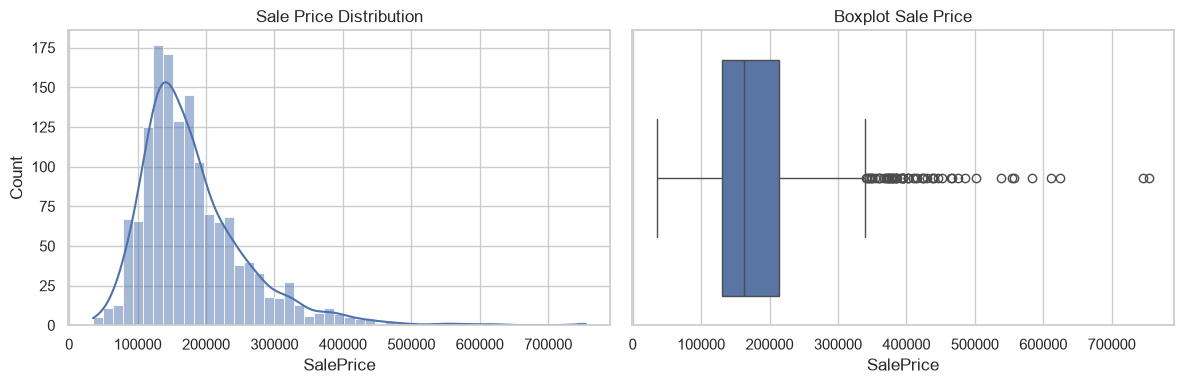

In [485]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Sale Price Distribution')

sns.boxplot(x=df['SalePrice'], ax=axes[1])
axes[1].set_title('Boxplot Sale Price')

plt.tight_layout()
plt.show()

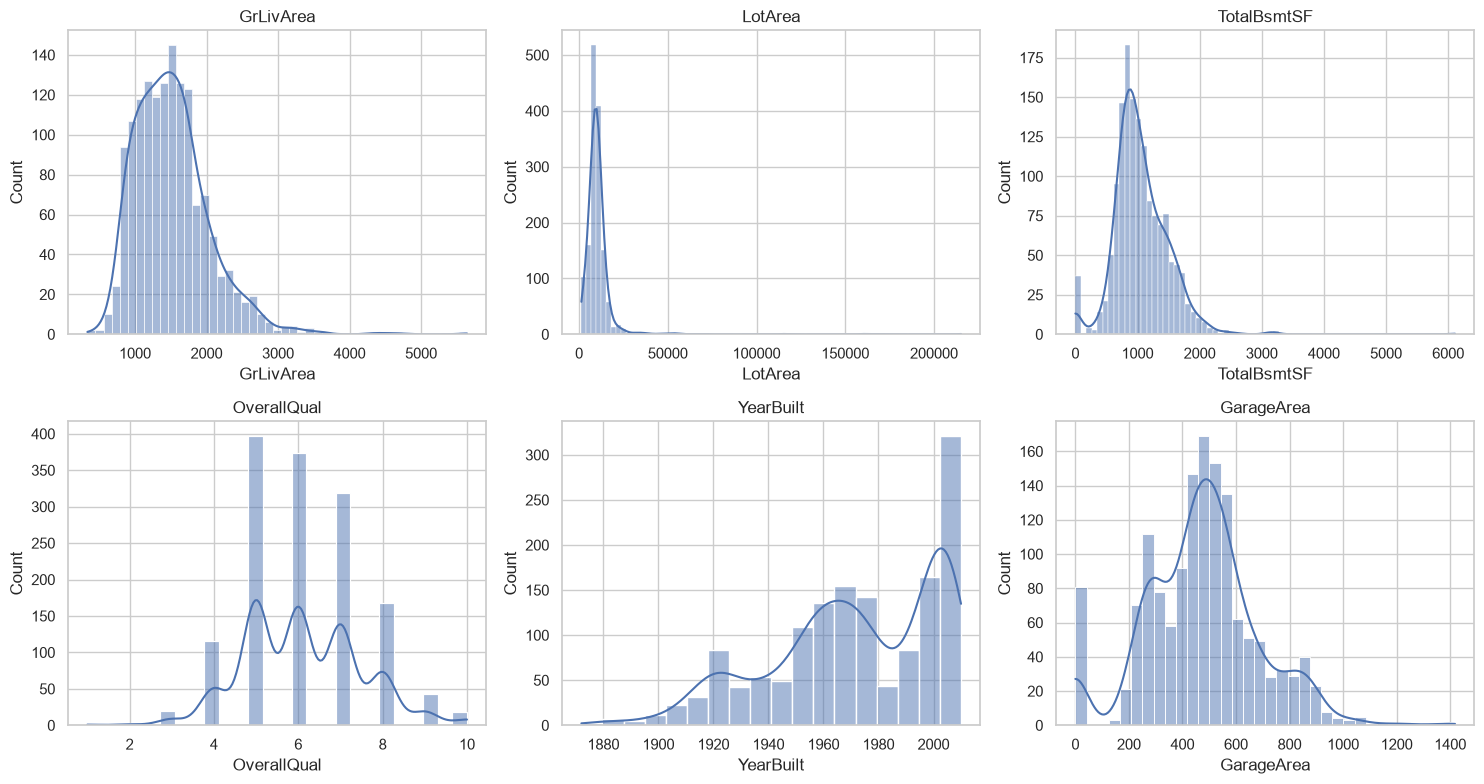

In [486]:
num_plot_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt', 'GarageArea']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, c in zip(axes, num_plot_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax)
    ax.set_title(c)

plt.tight_layout()
plt.show()

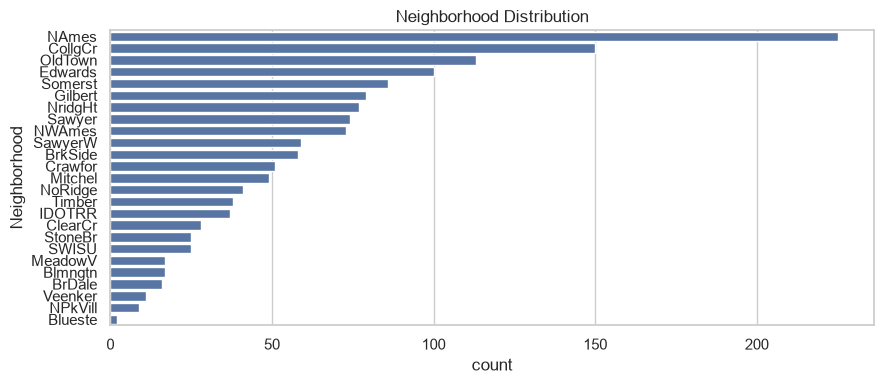

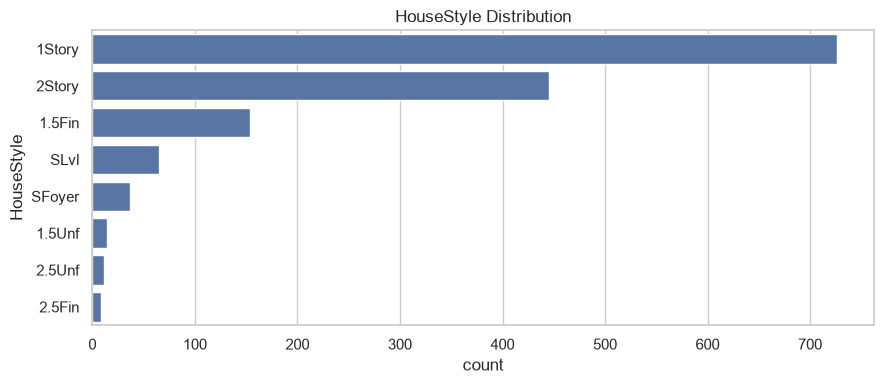

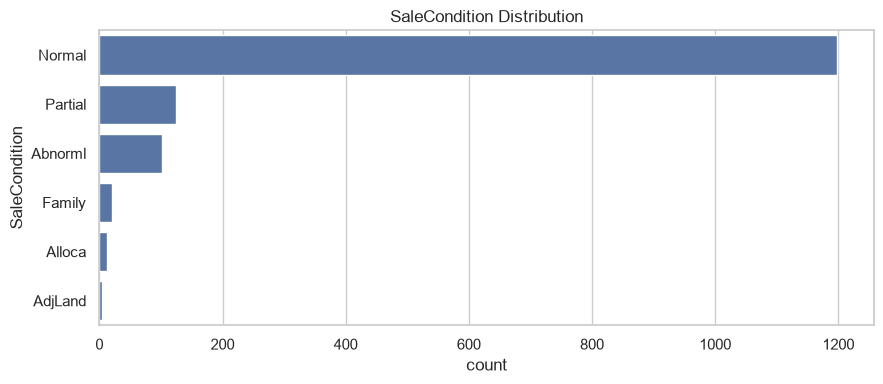

In [487]:
cat_plot_cols = ['Neighborhood', 'HouseStyle', 'SaleCondition']

for c in cat_plot_cols:
    plt.figure(figsize=(9,4))
    order = df[c].value_counts().index
    sns.countplot(df[c], order=order)
    plt.title(f'{c} Distribution')
    plt.tight_layout()
    plt.show()

### feature relationships

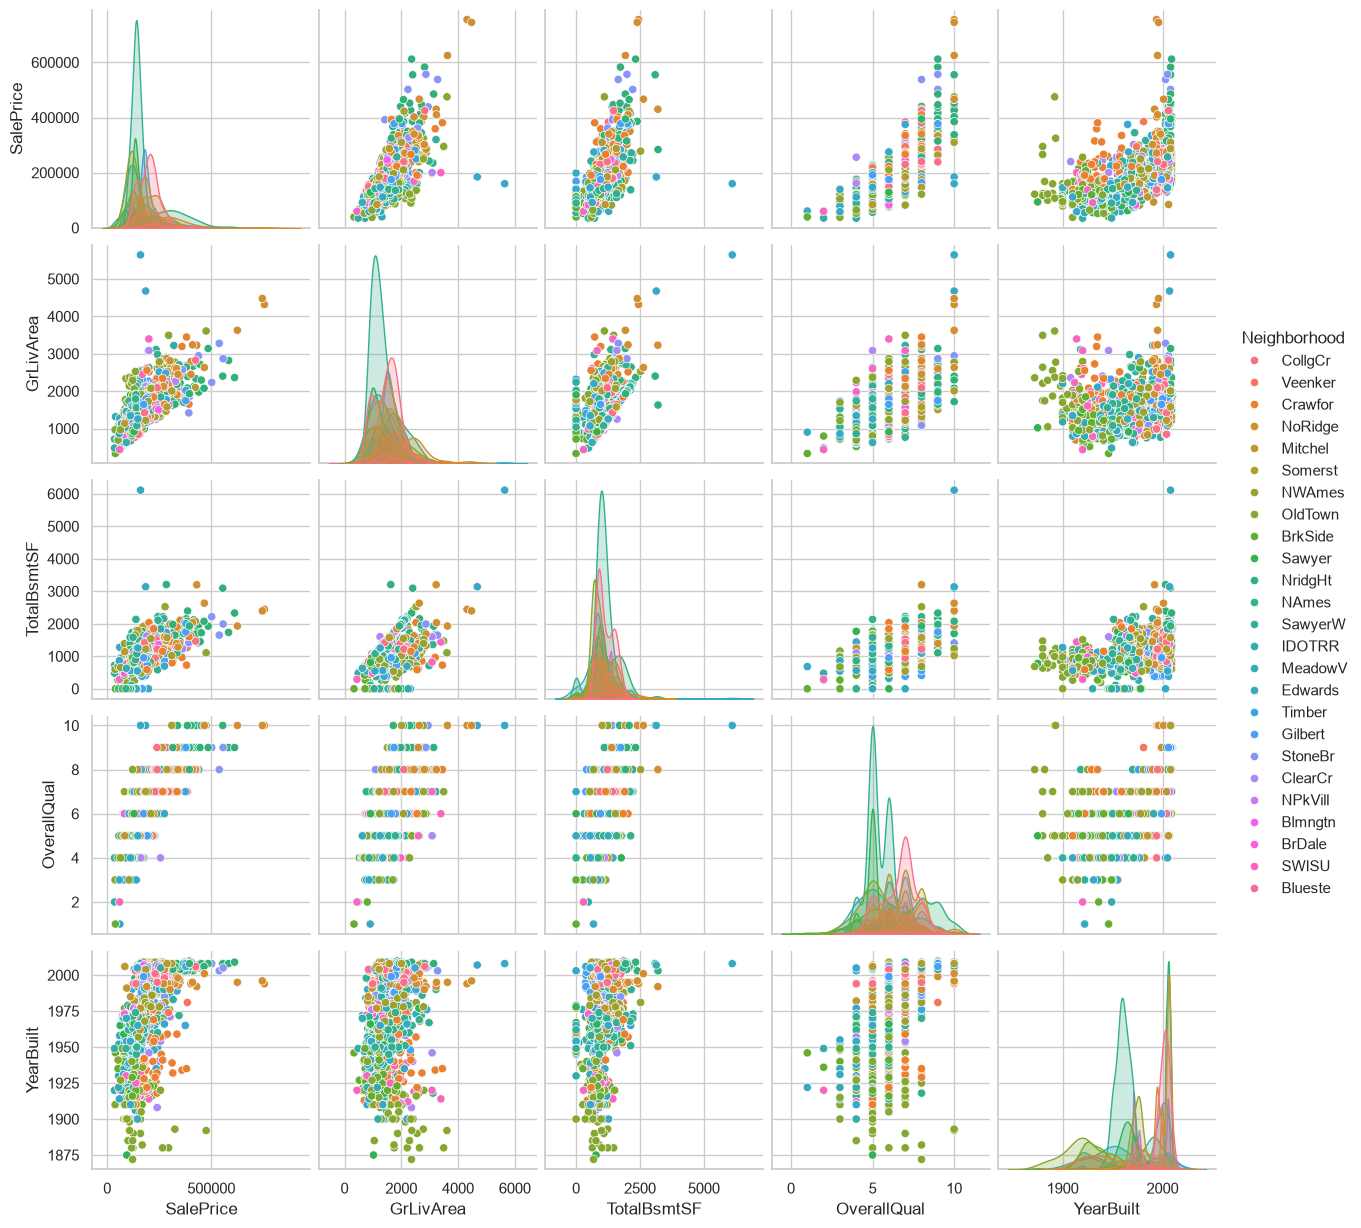

In [488]:
sns.pairplot(df, vars=['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt'], 
       hue='Neighborhood',
       diag_kind='kde')

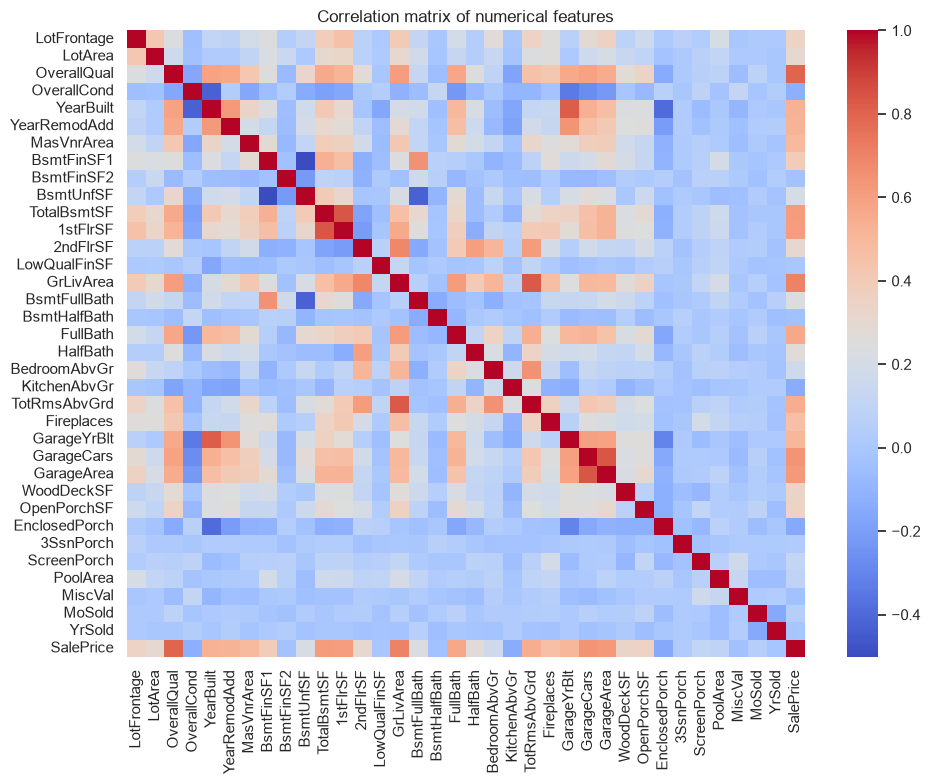

In [489]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].dropna().corr(), cmap='coolwarm')
plt.title('Correlation matrix of numerical features')
plt.tight_layout()
plt.show()

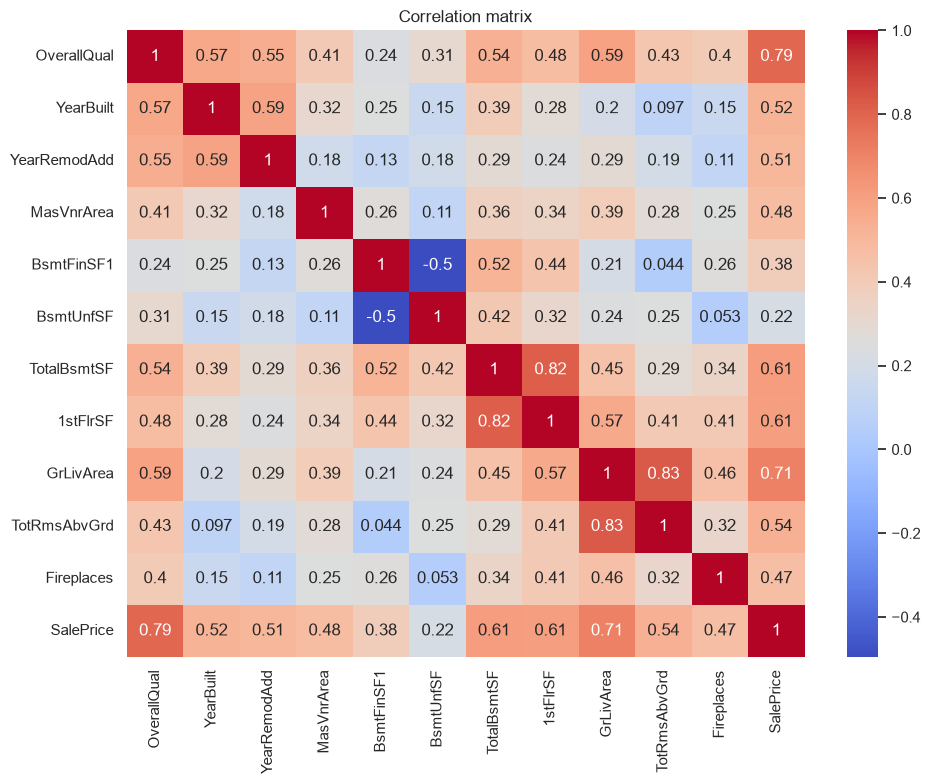

In [490]:
df_corr = df[[ 
       'OverallQual',
       'YearBuilt',
       'YearRemodAdd',
       'MasVnrArea',
       'BsmtFinSF1',
       'BsmtUnfSF',
       'TotalBsmtSF',
       '1stFlrSF',
       'GrLivArea',
       'TotRmsAbvGrd',
       'Fireplaces',
       'SalePrice']].dropna().corr()
plt.figure(figsize=(10,8))
sns.heatmap(df_corr, cmap='coolwarm', annot=True)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## 5. definition of input and output variables

In [491]:
TARGET = 'SalePrice'

X = df.drop(columns=[TARGET, 'Id'])
y = df[TARGET].copy()

print('X:', X.shape)
print('y:', y.shape)

X: (1460, 79)
y: (1460,)


## 6. split into training and test samples

In [492]:
price_bins = pd.qcut(y, q=5, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=price_bins
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (1168, 79) X_test: (292, 79)
y_train: (1168,) y_test: (292,)


## 7. processing of missed values

In [ ]:
missing_train = X_train.isna().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_train

PoolQC          1162
MiscFeature     1127
Alley           1098
Fence            940
MasVnrType       707
FireplaceQu      562
LotFrontage      211
GarageType        63
GarageYrBlt       63
GarageFinish      63
GarageQual        63
GarageCond        63
BsmtFinType2      32
BsmtCond          31
BsmtQual          31
BsmtExposure      31
BsmtFinType1      31
MasVnrArea         8
Electrical         1
dtype: int64

In [494]:
none_means_absence = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 
       'GarageType', 'GarageCond', 'GarageFinish', 'GarageQual', 'BsmtFinType2', 
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1']

for col in none_means_absence:
    X_train[col] = X_train[col].fillna('None')
    X_test[col] = X_test[col].fillna('None')

In [495]:
categorical_cols = X_train.select_dtypes(include=['str']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

remaining_cat = [c for c in categorical_cols if X_train[c].isna().any()]
remaining_num = [c for c in numeric_cols if X_train[c].isna().any()]

cat_imputer = SimpleImputer(strategy='most_frequent')
if remaining_cat:
    cat_imputer.fit(X_train[remaining_cat])
    X_train[remaining_cat] = cat_imputer.transform(X_train[remaining_cat])
    X_test[remaining_cat] = cat_imputer.transform(X_test[remaining_cat])
print('Filled with mode:', remaining_cat)


num_imputer = SimpleImputer(strategy='median')
if remaining_num:
    cat_imputer.fit(X_train[remaining_num])
    X_train[remaining_num] = cat_imputer.transform(X_train[remaining_num])
    X_test[remaining_num] = cat_imputer.transform(X_test[remaining_num])
print('Filled with median:', remaining_num)


Filled with mode: ['Electrical']
Filled with median: ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']


## 8. detection and analysis of outliers in numerical features

In [496]:
iqr_bounds = {}
for col in numeric_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_bounds[col] = (lower, upper)

outlier_report = pd.DataFrame({
    col: {
        'lower_bound': iqr_bounds[col][0],
        'upper_bound': iqr_bounds[col][1],
        'n_below_train': (X_train[col] < iqr_bounds[col][0]).sum(),
        'n_above_train': (X_train[col] > iqr_bounds[col][1]).sum(),
    } for col in numeric_cols
}).T.sort_values('n_above_train', ascending=False)

outlier_report[lambda s: s['n_above_train'] > 0]

,lower_bound,upper_bound,n_below_train,n_above_train
EnclosedPorch,0.000,0.000,0.0,176.0
BsmtFinSF2,0.000,0.000,0.0,135.0
ScreenPorch,0.000,0.000,0.0,95.0
OverallCond,3.500,7.500,26.0,80.0
MasVnrArea,-240.000,400.000,0.0,77.0
BsmtHalfBath,0.000,0.000,0.0,64.0
OpenPorchSF,-105.750,176.250,0.0,56.0
LotArea,1095.750,18173.750,0.0,55.0
KitchenAbvGr,1.000,1.000,0.0,53.0
LotFrontage,31.500,107.500,34.0,51.0


In [497]:
for col in numeric_cols:
    lower, upper = iqr_bounds[col]
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

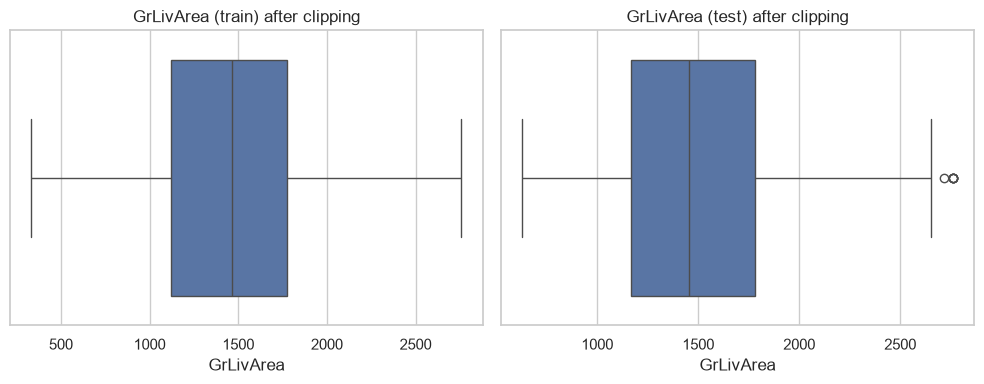

In [498]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(x=X_train['GrLivArea'], ax=axes[0])
axes[0].set_title('GrLivArea (train) after clipping')

sns.boxplot(x=X_test['GrLivArea'], ax=axes[1])
axes[1].set_title('GrLivArea (test) after clipping')

plt.tight_layout()
plt.show()

## 9. Encoding of categorical features

In [499]:
print('categorical_cols:', len(categorical_cols))
print('numeric_cols:', len(numeric_cols))

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[categorical_cols])

X_train_cat = pd.DataFrame(
    ohe.transform(X_train[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    ohe.transform(X_test[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_test.index
)

print('\nX_train_cat:', X_train_cat.shape)
print('X_test_cat:', X_test_cat.shape)


categorical_cols: 44
numeric_cols: 35

X_train_cat: (1168, 277)
X_test_cat: (292, 277)


## 10. scaling of numerical features

In [500]:
scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

X_train_num_scaled = pd.DataFrame(
    scaler.transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

print("Before scaling:")
display(X_train[numeric_cols].agg(['mean', 'std']).T.head(10))

print("\nAfter scaling:")
display(X_train_num_scaled.agg(['mean', 'std']).T.head(10))


Before scaling:


,mean,std
LotFrontage,67.792380,17.454971
LotArea,9738.995933,3695.829169
OverallQual,6.095034,1.395442
OverallCond,5.547945,0.976509
YearBuilt,1971.016802,30.187184
YearRemodAdd,1984.967466,20.883665
MasVnrArea,87.022260,131.446945
BsmtFinSF1,435.887735,431.309397
BsmtFinSF2,0.000000,0.000000
BsmtUnfSF,570.602312,442.914314



After scaling:


,mean,std
LotFrontage,3.239418e-16,1.000428
LotArea,1.783201e-16,1.000428
OverallQual,6.083414e-18,1.000428
OverallCond,-4.106304e-16,1.000428
YearBuilt,-3.199876e-15,1.000428
YearRemodAdd,-8.813346e-16,1.000428
MasVnrArea,-3.574006e-17,1.000428
BsmtFinSF1,3.041707e-17,1.000428
BsmtFinSF2,0.000000e+00,0.000000
BsmtUnfSF,1.520853e-17,1.000428


In [501]:
X_train_final = pd.concat([X_train_num_scaled.reset_index(drop=True), 
                           X_train_cat.reset_index(drop=True)], axis=1)

X_test_final = pd.concat([X_test_num_scaled.reset_index(drop=True), 
                           X_test_cat.reset_index(drop=True)], axis=1)

y_train_final = y_train.reset_index(drop=True)
y_test_final = y_test.reset_index(drop=True)

print('X_train_final:', X_train_final.shape)
print('X_test_final:', X_test_final.shape)


X_train_final: (1168, 312)
X_test_final: (292, 312)


## 11. Final check of data

In [502]:
checks = []

checks.append(("No missing data in X_train_final", 
               X_train_final.isna().sum().sum() == 0))
checks.append(("No missing data in X_test_final", 
               X_test_final.isna().sum().sum() == 0))
checks.append(("No missing data in y_train_final and y_test_final", 
               y_train_final.isna().sum() == 0 and y_test_final.isna().sum() == 0 ))
checks.append(("X_train_final.cols == X_test_final.cols", 
               X_train_final.shape[1] == X_test_final.shape[1]))
checks.append(("Same order of train/test columns",
               list(X_train_final.columns) == list(X_test_final.columns)))
checks.append(("X_train.shape == y_train.shape", 
               X_train_final.shape[0] == y_train_final.shape[0]))
checks.append(("X_test.shape == y_test.shape", 
               X_test_final.shape[0] == y_test_final.shape[0]))

for name, ok in checks:
    print(f"[{'OK' if ok else 'ERR'}] {name}")

[OK] No missing data in X_train_final
[OK] No missing data in X_test_final
[OK] No missing data in y_train_final and y_test_final
[OK] X_train_final.cols == X_test_final.cols
[OK] Same order of train/test columns
[OK] X_train.shape == y_train.shape
[OK] X_test.shape == y_test.shape
